In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
nsl_X_train = np.load("data/processed/nsl_X_train.npy")
nsl_y_train = np.load("data/processed/nsl_y_train.npy")
cic_X_train = np.load("data/processed/cic_X_train.npy")
cic_y_train = np.load("data/processed/cic_y_train.npy")

In [3]:
nsl_df = pd.DataFrame(nsl_X_train)
nsl_df["label"] = nsl_y_train

cic_df = pd.DataFrame(cic_X_train)
cic_df["label"] = cic_y_train

In [4]:
print("NSL Dataset Shape:", nsl_df.shape)
print("CIC Dataset Shape:", cic_df.shape)

print("\nNSL Class Distribution:\n", nsl_df["label"].value_counts())
print("\nCIC Class Distribution:\n", cic_df["label"].value_counts())

NSL Dataset Shape: (125973, 123)
CIC Dataset Shape: (2403694, 79)

NSL Class Distribution:
 label
0    67343
1    58630
Name: count, dtype: int64

CIC Class Distribution:
 label
0    1930622
1     473072
Name: count, dtype: int64


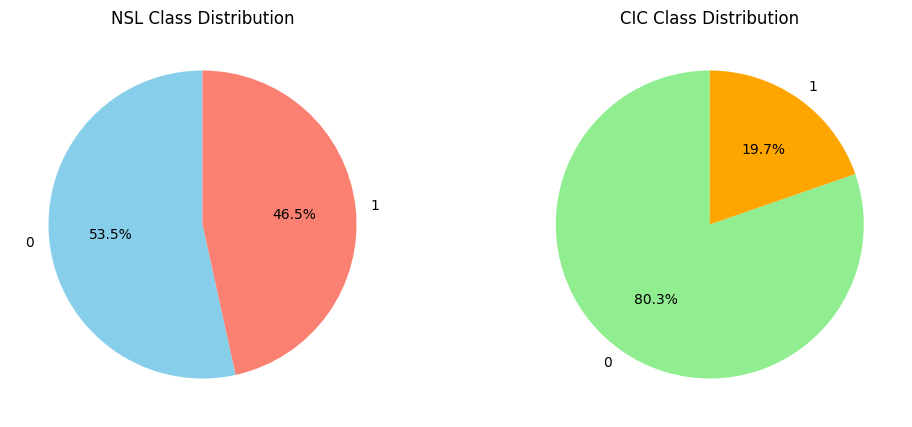

In [21]:
# Class Distribution Pie Charts

plt.figure(figsize=(12,5))

# NSL Pie Chart
plt.subplot(1,2,1)
nsl_counts = nsl_df["label"].value_counts()
plt.pie(nsl_counts, labels=nsl_counts.index, autopct="%1.1f%%", startangle=90, colors=["skyblue","salmon"])
plt.title("NSL Class Distribution")

# CIC Pie Chart
plt.subplot(1,2,2)
cic_counts = cic_df["label"].value_counts()
plt.pie(cic_counts, labels=cic_counts.index, autopct="%1.1f%%", startangle=90, colors=["lightgreen","orange"])
plt.title("CIC Class Distribution")

plt.show()

In [6]:
#  Statistical summary

print("\nNSL Statistical Summary:\n", nsl_df.describe())


NSL Statistical Summary:
                    0              1             2              3  \
count  125973.000000  125973.000000  1.259730e+05  125973.000000   
mean        0.164594       0.063053  1.509928e-05       0.714310   
std         0.224087       0.180314  3.069818e-03       0.389044   
min         0.000000       0.000000  0.000000e+00       0.000000   
25%         0.003914       0.000000  0.000000e+00       0.321569   
50%         0.027397       0.000000  0.000000e+00       1.000000   
75%         0.279843       0.060000  3.939120e-07       1.000000   
max         1.000000       1.000000  1.000000e+00       1.000000   

                   4              5              6              7  \
count  125973.000000  125973.000000  125973.000000  125973.000000   
mean        0.082951       0.118832       0.148379       0.521242   
std         0.188922       0.306557       0.308997       0.448949   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.0

In [7]:
print("\nCIC Statistical Summary:\n", cic_df.describe())


CIC Statistical Summary:
                   0             1             2          3             4  \
count  2.403694e+06  2.403694e+06  2.403694e+06  2403694.0  2.403694e+06   
mean  -3.363925e-06  2.903578e-04  6.484089e-07        0.0  3.899147e-05   
std    9.998490e-01  1.028093e+00  1.000002e+00        0.0  9.992111e-01   
min   -2.368044e-01 -7.145420e-03 -2.205749e-01        0.0 -3.129142e-01   
25%   -2.368044e-01 -7.144537e-03 -2.205749e-01        0.0 -2.806862e-01   
50%   -2.368044e-01 -7.091096e-03 -2.205749e-01        0.0 -1.302887e-01   
75%   -2.342724e-01 -6.931658e-03 -2.205749e-01        0.0 -4.434727e-02   
max    1.320241e+01  2.894779e+02  4.533608e+00        0.0  3.159744e+01   

                  5             6             7             8             9  \
count  2.403694e+06  2.403694e+06  2.403694e+06  2.403694e+06  2.403694e+06   
mean   3.678949e-04  9.708363e-05  2.996321e-04  2.492404e-04  2.936611e-04   
std    1.004225e+00  1.000345e+00  1.030426e+00  1.

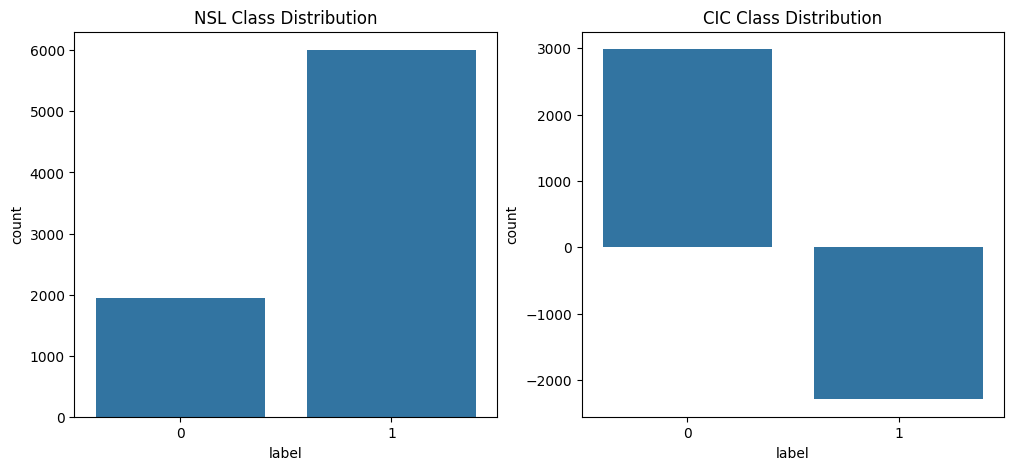

In [8]:
# Class distribution plots

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(x="label", data=nsl_df)
plt.title("NSL Class Distribution")

plt.subplot(1,2,2)
sns.countplot(x="label", data=cic_df)
plt.title("CIC Class Distribution")
plt.show()

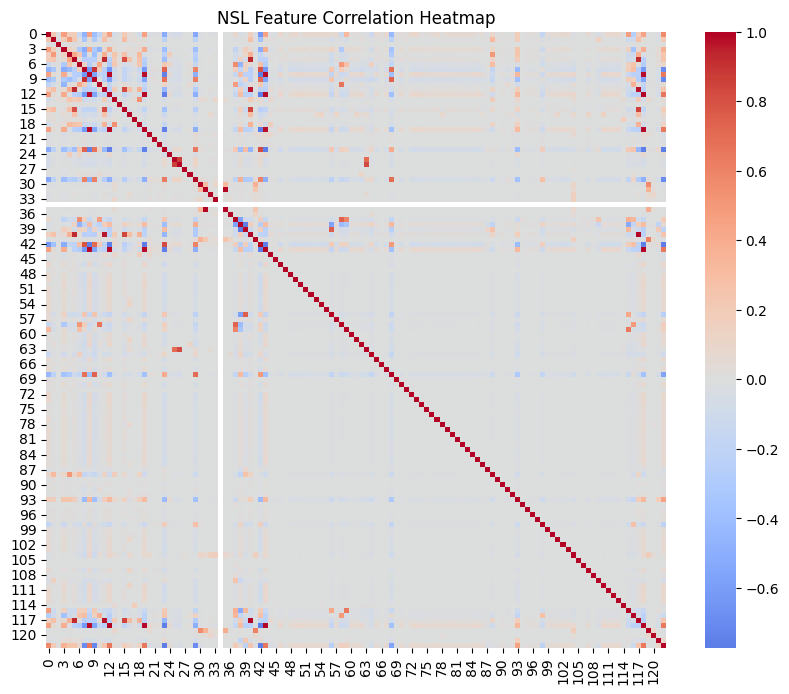

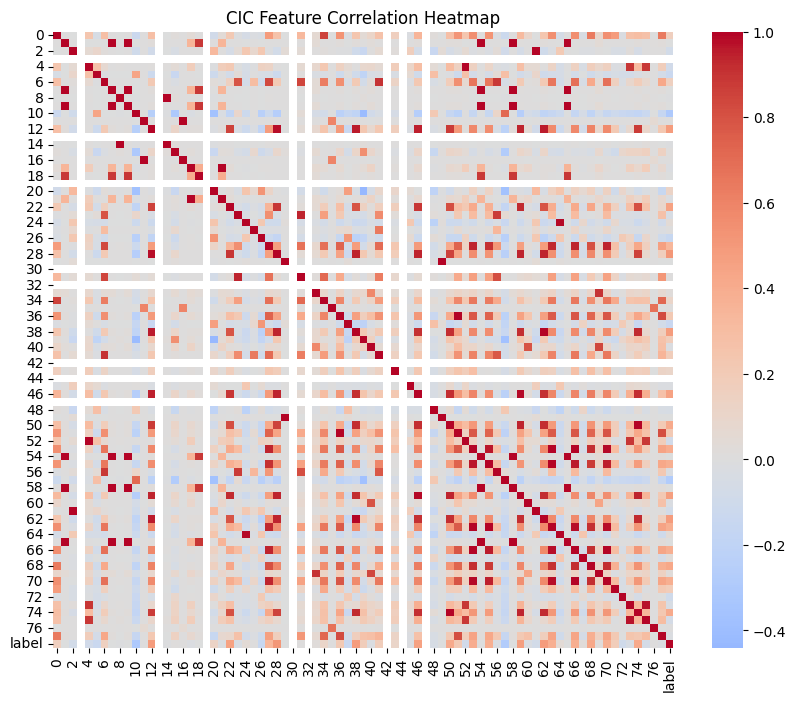

In [9]:
#  Correlation heatmap

plt.figure(figsize=(10,8))
sns.heatmap(nsl_df.corr(), cmap="coolwarm", center=0)
plt.title("NSL Feature Correlation Heatmap")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(cic_df.corr(), cmap="coolwarm", center=0)
plt.title("CIC Feature Correlation Heatmap")
plt.show()

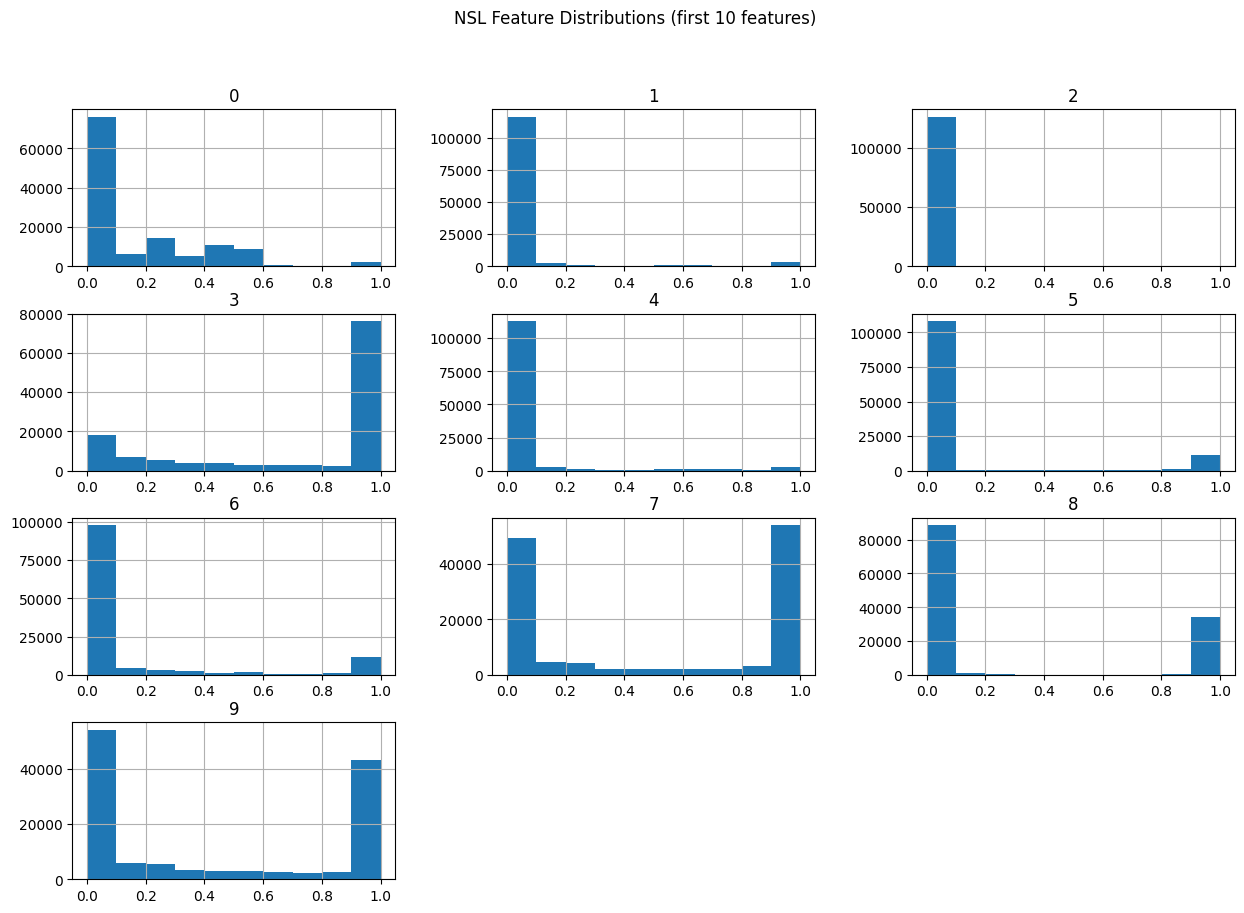

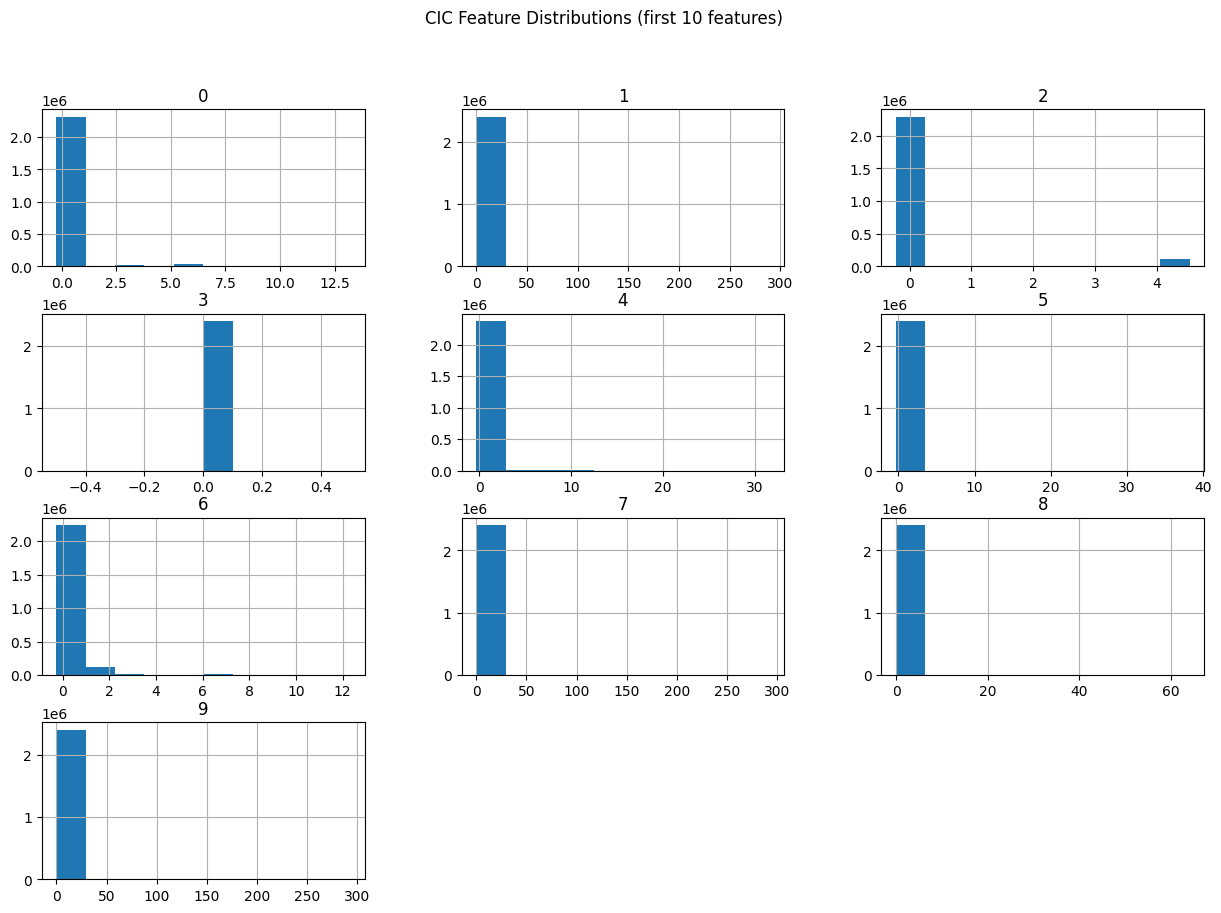

In [11]:
#  Feature distribution histograms

nsl_df.iloc[:,:10].hist(figsize=(15,10))
plt.suptitle("NSL Feature Distributions (first 10 features)")
plt.show()

cic_df.iloc[:,:10].hist(figsize=(15,10))
plt.suptitle("CIC Feature Distributions (first 10 features)")
plt.show()

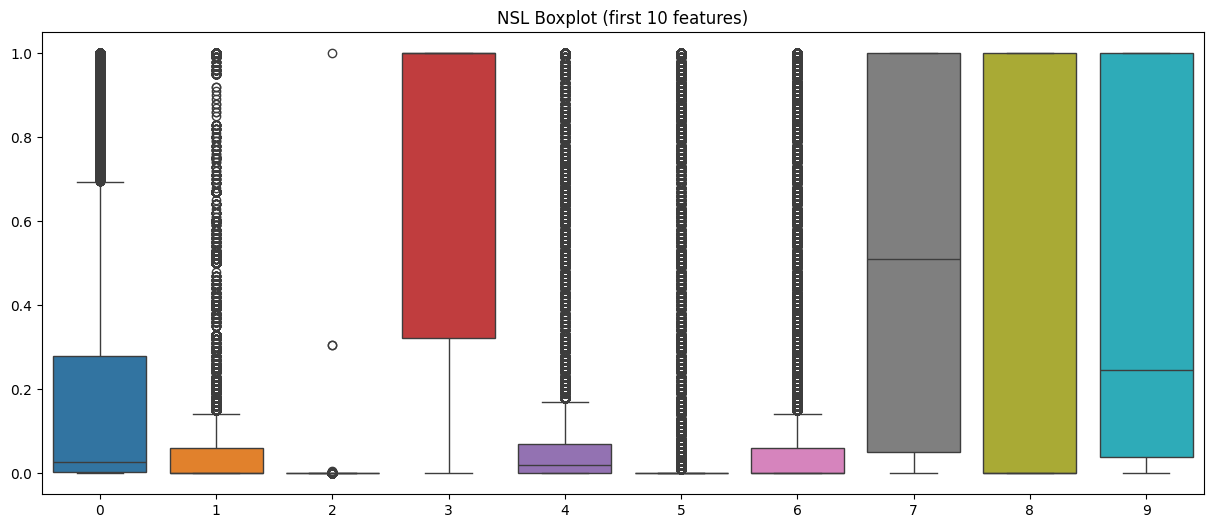

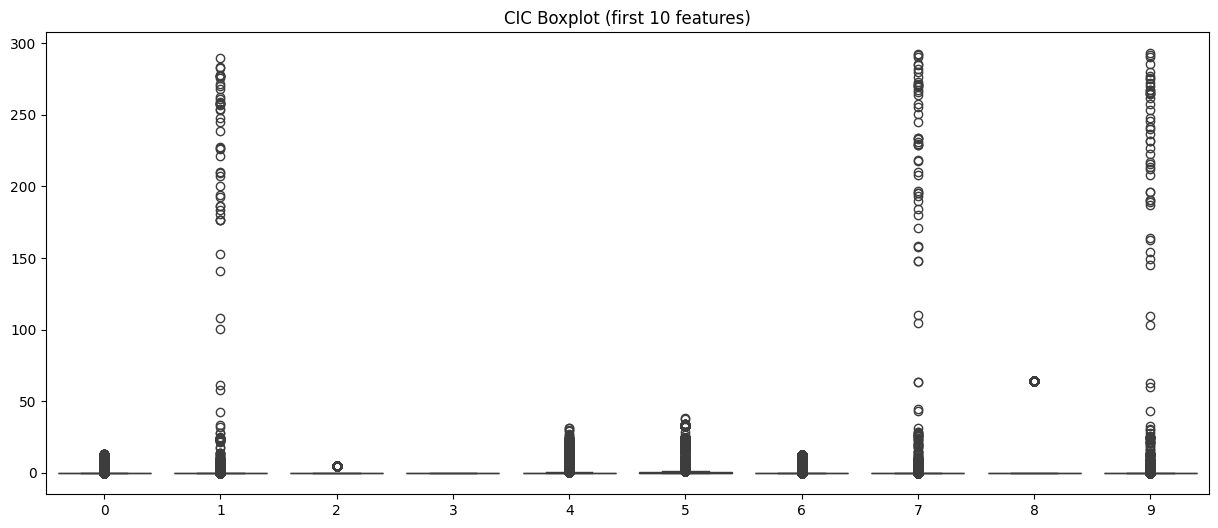

In [12]:
#  Boxplots for outlier detection

plt.figure(figsize=(15,6))
sns.boxplot(data=nsl_df.iloc[:,:10])
plt.title("NSL Boxplot (first 10 features)")
plt.show()

plt.figure(figsize=(15,6))
sns.boxplot(data=cic_df.iloc[:,:10])
plt.title("CIC Boxplot (first 10 features)")
plt.show()

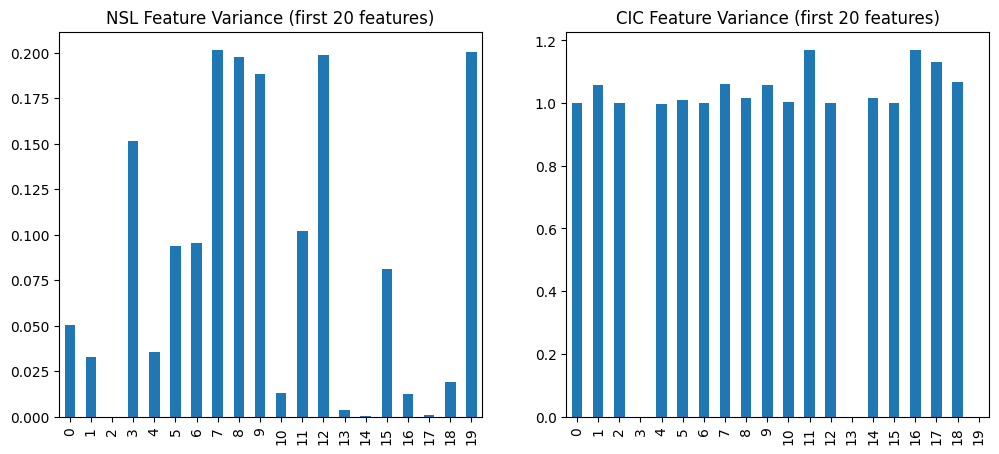

In [13]:
# Variance of each feature
nsl_variances = nsl_df.var()
cic_variances = cic_df.var()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
nsl_variances[:20].plot(kind="bar")
plt.title("NSL Feature Variance (first 20 features)")

plt.subplot(1,2,2)
cic_variances[:20].plot(kind="bar")
plt.title("CIC Feature Variance (first 20 features)")
plt.show()

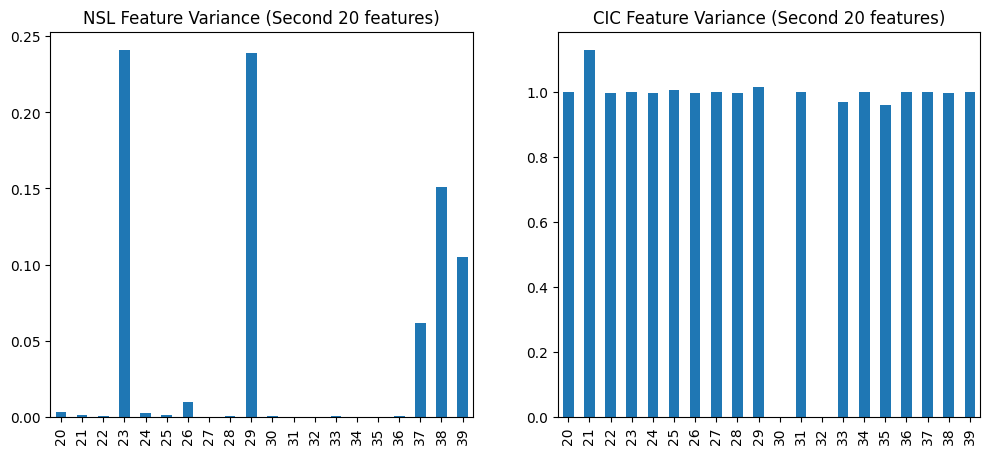

In [14]:
# Variance of each feature
nsl_variances = nsl_df.var()
cic_variances = cic_df.var()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
nsl_variances[20:40].plot(kind="bar")
plt.title("NSL Feature Variance (Second 20 features)")

plt.subplot(1,2,2)
cic_variances[20:40].plot(kind="bar")
plt.title("CIC Feature Variance (Second 20 features)")
plt.show()

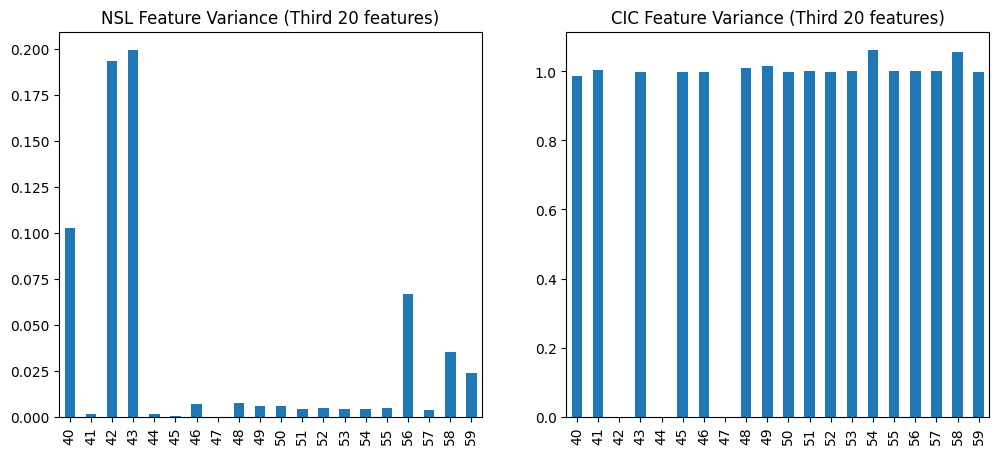

In [15]:
# Variance of each feature
nsl_variances = nsl_df.var()
cic_variances = cic_df.var()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
nsl_variances[40:60].plot(kind="bar")
plt.title("NSL Feature Variance (Third 20 features)")

plt.subplot(1,2,2)
cic_variances[40:60].plot(kind="bar")
plt.title("CIC Feature Variance (Third 20 features)")
plt.show()

In [17]:
corr_nsl = nsl_df.corr()["label"].sort_values(ascending=False)
corr_cic = cic_df.corr()["label"].sort_values(ascending=False)

print("Top 20 NSL Features correlated with label:\n", corr_nsl.head(20))
print("\nTop 20 CIC Features correlated with label:\n", corr_cic.head(20))

Top 20 NSL Features correlated with label:
 label    1.000000
12       0.654985
8        0.651842
43       0.650652
19       0.650206
118      0.648289
0        0.576444
93       0.449720
3        0.375052
117      0.253504
11       0.253430
40       0.253397
5        0.252563
4        0.242898
1        0.203660
37       0.200455
15       0.184949
58       0.166083
59       0.149994
18       0.133099
Name: label, dtype: float64

Top 20 CIC Features correlated with label:
 label    1.000000
28       0.510600
12       0.492354
38       0.484539
62       0.484539
59       0.470585
46       0.454389
22       0.454328
68       0.423592
74       0.414337
50       0.413325
53       0.394991
63       0.391180
66       0.389409
70       0.389391
55       0.381304
27       0.337557
51       0.216058
36       0.214457
71       0.189458
Name: label, dtype: float64


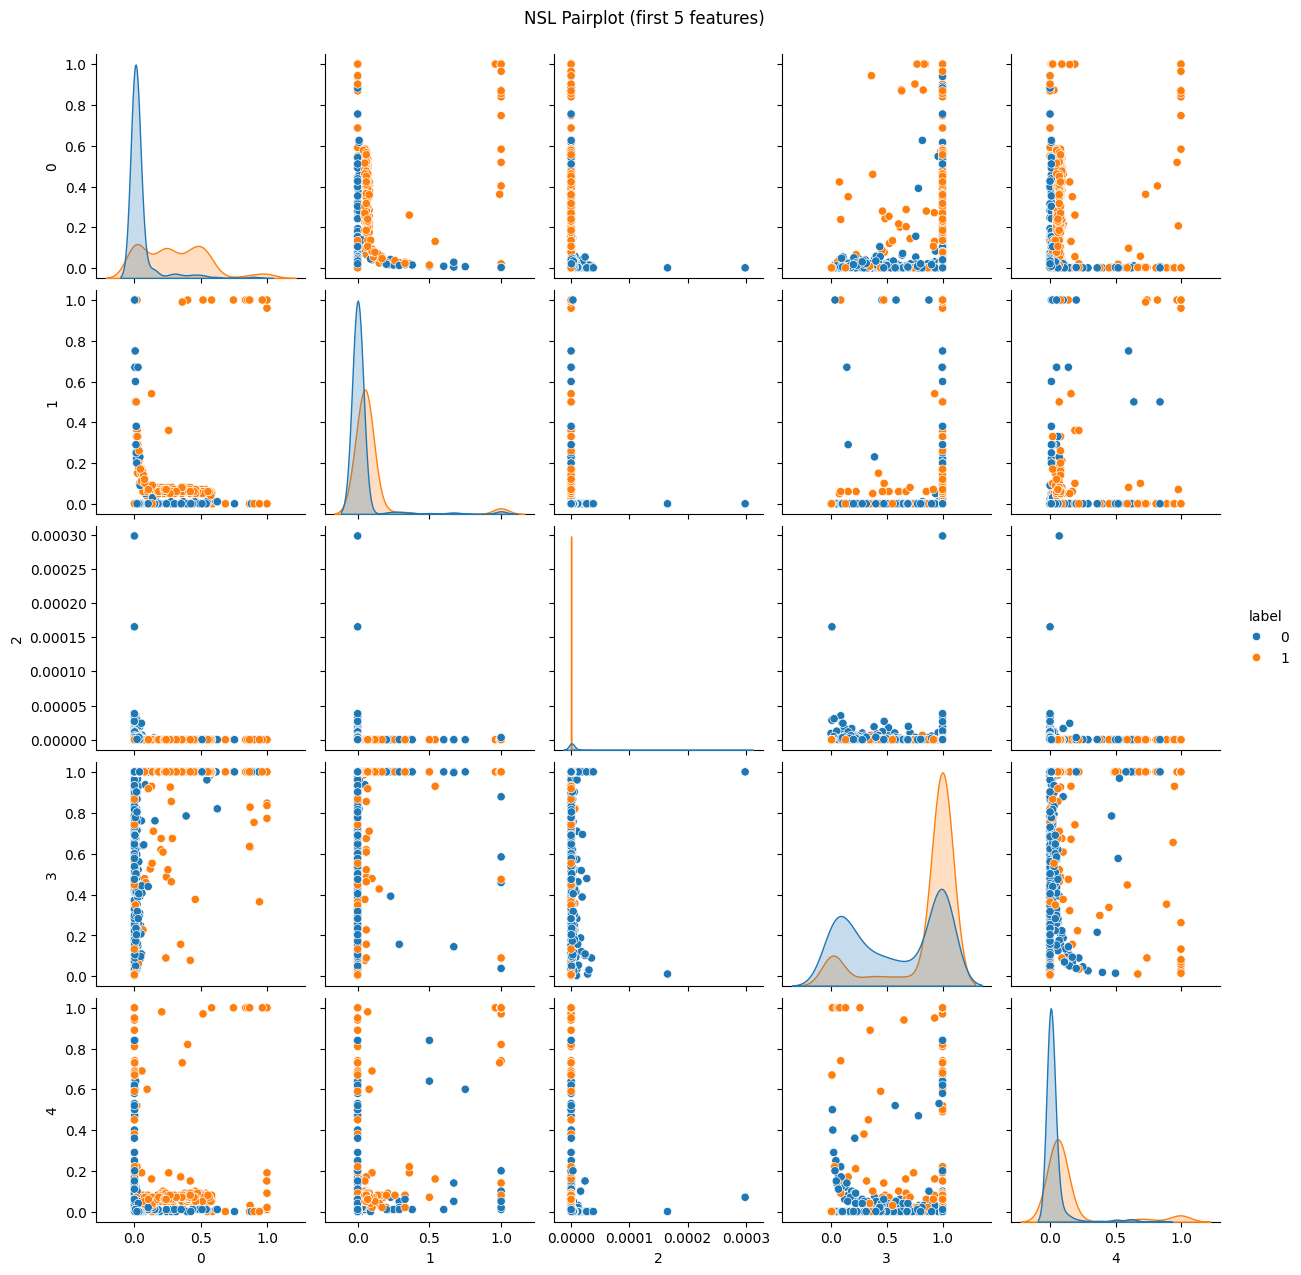

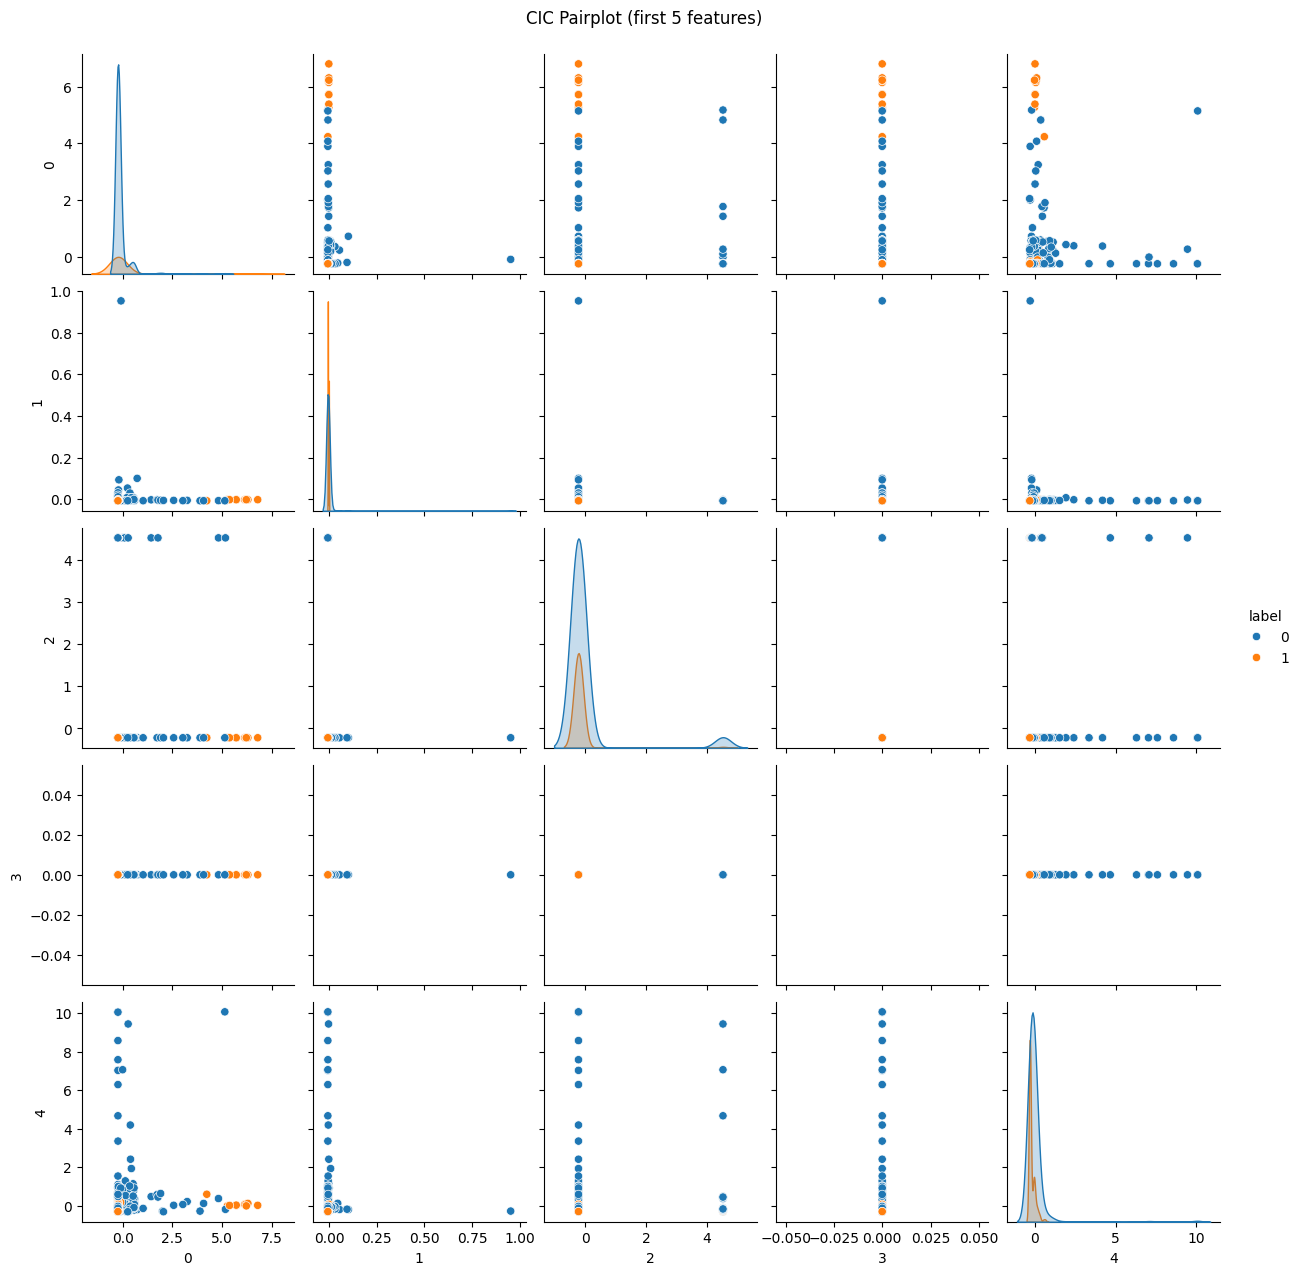

In [18]:
import seaborn as sns

# Sample 1000 rows for visualization
sns.pairplot(nsl_df.sample(1000), vars=nsl_df.columns[:5], hue="label")
plt.suptitle("NSL Pairplot (first 5 features)", y=1.02)
plt.show()

sns.pairplot(cic_df.sample(1000), vars=cic_df.columns[:5], hue="label")
plt.suptitle("CIC Pairplot (first 5 features)", y=1.02)
plt.show()

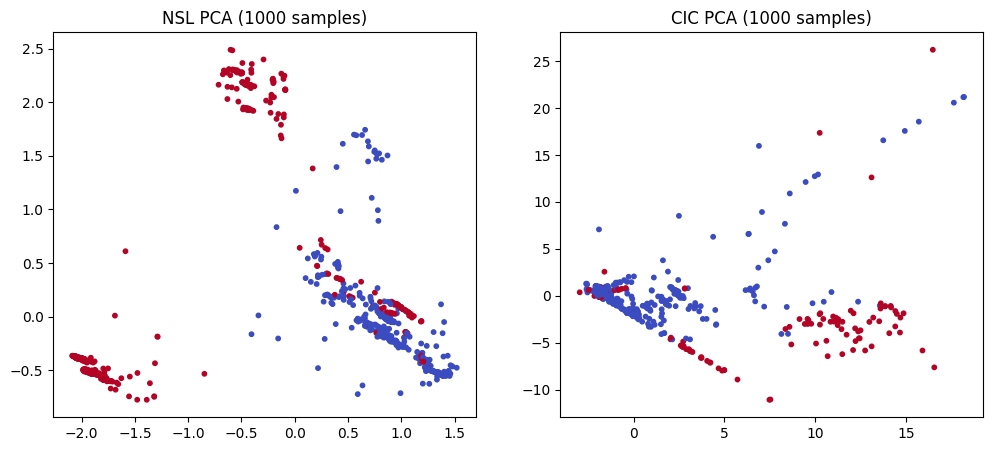

In [19]:
from sklearn.decomposition import PCA

pca_nsl = PCA(n_components=2).fit_transform(nsl_X_train[:1000])
pca_cic = PCA(n_components=2).fit_transform(cic_X_train[:1000])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(pca_nsl[:,0], pca_nsl[:,1], c=nsl_y_train[:1000], cmap="coolwarm", s=10)
plt.title("NSL PCA (1000 samples)")

plt.subplot(1,2,2)
plt.scatter(pca_cic[:,0], pca_cic[:,1], c=cic_y_train[:1000], cmap="coolwarm", s=10)
plt.title("CIC PCA (1000 samples)")
plt.show()

In [20]:
nsl_ratio = nsl_df["label"].value_counts(normalize=True)
cic_ratio = cic_df["label"].value_counts(normalize=True)

print("NSL Class Ratio:\n", nsl_ratio)
print("\nCIC Class Ratio:\n", cic_ratio)

NSL Class Ratio:
 label
0    0.534583
1    0.465417
Name: proportion, dtype: float64

CIC Class Ratio:
 label
0    0.80319
1    0.19681
Name: proportion, dtype: float64
